# 03 - plot_psd_waterfall\nDerived from `notebooks/prior_versions/plume_path_plot_clean.ipynb`.\n

In [1]:
import os, platform, socket

def is_server() -> bool:
    # strong signals
    if os.getenv("JUPYTERHUB_API_URL") or os.getenv("JUPYTERHUB_USER"):
        return True
    if os.getenv("SLURM_JOB_ID"):
        return True

    # fallback heuristic (common: local macOS, server Linux)
    return platform.system() != "Darwin"

print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())

system: Darwin 25.3.0
hostname: 22182-mbp-2.tropos.de
is_server: False


In [2]:
from __future__ import annotations

import re, sys
from pathlib import Path
import colormaps as pcmaps
import matplotlib.axes as maxes
import matplotlib.dates as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import LogNorm, ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator, LogLocator, FuncFormatter



xr.set_options(keep_attrs=True)

sys.path.insert(0, str((Path.cwd() / ".." / "src").resolve()))
from utilities import make_pastel, load_plume_path_runs
from utilities.holimo_helpers import load_and_prepare_holimo

def create_new_jet3(n_colors=256, n_ice_colors=32):
    ice_colors = pcmaps.ice(np.linspace(1, 0.5, n_ice_colors))
    bk_colors  = pcmaps.BkBlAqGrYeOrReViWh200(np.linspace(0.1, 0.9, n_colors))
    transition = np.linspace(ice_colors[-1], bk_colors[0], 16)[1:-1]
    return ListedColormap(np.vstack([ice_colors, transition, bk_colors]))

new_jet4 = create_new_jet3(1024)

new_jet3 = create_new_jet3()
new_jet3_soft = make_pastel(new_jet3, desaturation=0.25, darken=0.90)


In [3]:
def format_axis_ticks(
    self,
    *,
    y_tick_pos: str = "both",
    x_tick_pos: str = "bottom",
    y_tick_labels: bool = False,
    x_tick_labels: bool = False,
    y_label: str = "",
    x_label: str = "",
    grid: bool = True,
):
    self.tick_params(which="both", direction="out", top=True, right=True, bottom=True, left=True)
    self.minorticks_on()
    self.tick_params(which="major", direction="out", length=5, width=0.9)
    self.tick_params(which="minor", direction="out", length=3, width=0.5)
    self.set_xlabel(x_label)
    self.set_ylabel(y_label)
    self.yaxis.set_ticks_position(y_tick_pos)
    self.xaxis.set_ticks_position(x_tick_pos)
    if not y_tick_labels:
        self.yaxis.set_ticklabels([])
    else:
        self.yaxis.set_major_formatter(plt.FuncFormatter(
            lambda x, p: f'{x:.3f}'.rstrip('0').rstrip('.') if x < 1 else f'{x:.0f}'))
    if not x_tick_labels:
        self.xaxis.set_ticklabels([])
    if grid:
        self.grid(True, which="major", linestyle="--", linewidth=0.25, color="black", alpha=0.6)
        self.grid(True, which="minor", linestyle=":", linewidth=0.15, color="black", alpha=0.35)
    self.set_axisbelow(False)


def format_elapsed_time(
    self,
    t0,
    t_end,
    *,
    major_interval: int = 5,
    minor_interval: int = 1,
    max_major_ticks: int = 14,
    max_minor_ticks: int = 180,
):
    """Format elapsed-time axis in minutes (numeric x axis)."""
    duration_min = float((t_end - t0) / np.timedelta64(1, "m"))
    if not np.isfinite(duration_min) or duration_min <= 0:
        return

    major_step = max(int(major_interval), int(np.ceil(duration_min / max_major_ticks)))
    minor_step = max(int(minor_interval), int(np.ceil(duration_min / max_minor_ticks)))

    major_times = np.arange(0, duration_min + major_step, major_step)
    minor_times = np.arange(0, duration_min + minor_step, minor_step)

    self.xaxis.set_major_locator(FixedLocator(major_times))
    self.xaxis.set_minor_locator(FixedLocator(minor_times))
    self.set_xticklabels([f"+{int(t):02d}" for t in major_times])


def add_missing_data_patches(
    self,
    da: xr.DataArray,
    *,
    min_consecutive: int = 2,
    add_legend: bool = True,
    y_extend=(1, 1000),
    **patch_kw,
):
    if "time" not in da.dims:
        return

    if "diameter" in da.dims:
        dvals = da["diameter"].values
        y0, y1 = dvals[0] - y_extend[0], dvals[-1] + y_extend[1]
    else:
        y0, y1 = y_extend

    collapse_dims = [d for d in da.dims if d not in {"time", "diameter"}]
    d1 = da.sum(dim=collapse_dims) if collapse_dims else da
    mask = ~(d1.sum(dim="diameter") > 0) if "diameter" in d1.dims else ~(d1 > 0)
    mask = np.asarray(mask).ravel()
    if not mask.any():
        return

    ti = np.where(mask)[0]
    split = np.where(np.diff(ti) > 1)[0] + 1
    starts = np.r_[0, split]
    ends = np.r_[split, len(ti)]
    tvals = d1["time"].values

    opts = {
        "facecolor": "lightgray",
        "edgecolor": "black",
        "alpha": 0.2,
        "linewidth": 0.2,
        "hatch": "///",
        "zorder": 1,
        **patch_kw,
    }
    for s, e in zip(starts, ends):
        if e - s < min_consecutive:
            continue
        t0, t1 = tvals[ti[s]], tvals[ti[e - 1]]
        x0, x1 = md.date2num(t0), md.date2num(t1)
        self.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, **opts))


maxes.Axes.format_axis_ticks = format_axis_ticks
maxes.Axes.format_elapsed_time = format_elapsed_time
maxes.Axes.add_missing_data_patches = add_missing_data_patches


In [5]:
def _prepare_da(ds: xr.Dataset, variable: str, *, sum_cell=True) -> xr.DataArray:
    if variable not in ds:
        raise KeyError(f"Variable '{variable}' missing. Available: {list(ds.data_vars)}")
    da = ds[variable]
    if sum_cell and "cell" in da.dims:
        da = da.sum("cell", keep_attrs=True, skipna=True)
    # if zlim is not None and "altitude" in da.coords:
    #     z0, z1 = zlim
    #     da = da.where((da.altitude >= z0) & (da.altitude <= z1), drop=True)
    return da


def _assign_elapsed_time(da: xr.DataArray, t0) -> xr.DataArray:
    mins = (da.time - t0) / np.timedelta64(1, "m")
    return da.assign_coords(time_elapsed=("time", mins.values))


def build_common_xlim(
    ds_by_run: dict[str, dict[str, xr.Dataset]],
    *,
    kind: str = "integrated",
    span_min: int = 35,
    anchor: np.datetime64 | None = None,
):
    starts = []
    for run in ds_by_run.values():
        ds = run.get(kind)
        if not isinstance(ds, xr.Dataset):
            continue
        if "time" not in ds.coords or ds.time.size == 0:
            continue
        starts.append(np.datetime64(ds.time.values.min(), "s"))

    if not starts:
        raise ValueError(f"Cannot infer xlim: no datasets with kind='{kind}' and valid time")

    if anchor is None:
        # Domain-specific default: start one minute before flare ignition.
        day = str(min(starts))[:10]
        t0 = np.datetime64(f"{day}T12:29:00")
    else:
        t0 = np.datetime64(anchor, "s")

    return [t0, t0 + np.timedelta64(int(span_min), "m")]


def _plume_path_intervals(xl):
    if xl:
        dt = np.diff(xl)[0]
        if dt < np.timedelta64(5, "m"):
            return 1, 1
        if dt < np.timedelta64(30, "m"):
            return 5, 1
        if dt < np.timedelta64(60, "m"):
            return 15, 1
        return 30, 10
    return 15, 1


def _plume_path_major_locs_from_span(span):
    if span <= 10:
        return np.array([0.1, 1, 2, 5, 10])
    if span <= 60:
        return np.array([0.1, 1, 2, 5, 10, 20, 50])
    return np.array([0.1, 1, 5, 10, 30, 60, 120])


def _plume_path_log_axis_params(xl):
    t0 = xl[0]
    x_min = float((xl[0] - t0) / np.timedelta64(1, "m"))
    x_max = float((xl[1] - t0) / np.timedelta64(1, "m"))
    if x_min <= 0:
        x_min = 0.1
    span = x_max - x_min
    major_locs = _plume_path_major_locs_from_span(span)
    return t0, x_min, x_max, span, major_locs


def compute_holimo_elapsed_anchors(
    ds_hd10,
    obs_ids,
    time_frames_plume,
    growth_times_min=None,
    seeding_start_times=None,
    var_candidates=None,
):
    if var_candidates is None:
        var_candidates = sorted([v for v in ds_hd10.data_vars if v.startswith("Ice_") and v.endswith("PSDlogNorm")])

    anchors = {}
    for i, (obs_id, (t_lo, t_hi)) in enumerate(zip(obs_ids, time_frames_plume)):
        ds_ = ds_hd10.sel(time=slice(t_lo, t_hi))
        if ds_.time.size == 0:
            anchors[obs_id] = np.nan
            continue

        # Preferred: elapsed time is referenced to mission seeding start.
        if seeding_start_times is not None and i < len(seeding_start_times):
            seed_t = np.datetime64(seeding_start_times[i])
            anchors[obs_id] = float((np.datetime64(ds_.time.values[0]) - seed_t) / np.timedelta64(1, "m"))
            continue

        # Fallback: infer anchor from first non-zero signal + growth time.
        first_idx = None
        for var in var_candidates:
            if var not in ds_.data_vars:
                continue
            arr = np.asarray(ds_[var].values)
            nz = np.isfinite(arr) & (arr > 0)
            if not nz.any():
                continue
            time_hit = int(np.argmax(nz.any(axis=tuple(range(1, arr.ndim)))))
            first_idx = time_hit if first_idx is None else min(first_idx, time_hit)

        if first_idx is None:
            anchors[obs_id] = np.nan
            continue

        dt_min = float((ds_.time[1] - ds_.time[0]).values / np.timedelta64(1, "m")) if ds_.time.size > 1 else 0.0
        growth_min = float(growth_times_min[i]) if growth_times_min is not None and i < len(growth_times_min) else 0.0
        anchors[obs_id] = growth_min + first_idx * dt_min

    return anchors


def diagnostics_table(
    ds_by_run: dict[str, dict[str, xr.Dataset]],
    *,
    kind: str = "integrated",
    variable: str = "nf",
    xlim=None,
) -> pd.DataFrame:
    rows = []
    for label, run in ds_by_run.items():
        ds = run.get(kind)
        if ds is None:
            rows.append({"run": label, "status": "missing kind"})
            continue
        if not isinstance(ds, xr.Dataset):
            rows.append({"run": label, "status": f"invalid kind type: {type(ds).__name__}"})
            continue

        row = {
            "run": label,
            "status": "ok",
            "n_cells": int(ds.sizes.get("cell", 1)),
            "n_time": int(ds.sizes.get("time", 0)),
            "time_min": str(ds.time.values.min()).split(".")[0] if "time" in ds.coords and ds.time.size else "-",
            "time_max": str(ds.time.values.max()).split(".")[0] if "time" in ds.coords and ds.time.size else "-",
            "has_var": variable in ds,
        }

        if variable in ds and "time" in ds[variable].dims and xlim is not None:
            in_win = ds[variable].sel(time=slice(xlim[0], xlim[1]))
            row["n_time_in_xlim"] = int(in_win.sizes.get("time", 0))
            row["finite_in_xlim"] = int(np.isfinite(in_win.values).sum())
        rows.append(row)

    return pd.DataFrame(rows)


def _plume_path_annotate_letters(axes):
    for i, ax in enumerate(np.atleast_1d(axes).flatten()):
        ax.text(0.02, 0.98, f'({chr(65+i)})', transform=ax.transAxes, ha='left', va='top', fontweight='semibold', fontsize=14)


def plot_plume_path_sum(
    ds_by_run: dict[str, dict[str, xr.Dataset]],
    *,
    kind: str = "integrated",
    variable: str = "nf",
    xlim=None,
    common_xlim_minutes: int | None = 35,
    ylim=(1, 2000),
    zlim=None,
    cmap="viridis",
    log_norm=True,
    x_axis_fmt: str = "elapsed",  # 'datetime', 'elapsed', 'log', 'symlog'
    add_missing_data=True,
    figsize_scale=(6.5, 3.6),
    annote_letters=True,
    holimo_overlay: dict | None = None,
    symlog_shift_start_idx: int = 0,
    symlog_panel_shift_min: float = 1.0,
):
    labels = [k for k, v in ds_by_run.items() if isinstance(v.get(kind), xr.Dataset)]
    if not labels:
        raise ValueError(f"No datasets available for kind='{kind}'")

    if x_axis_fmt in {"elapsed", "log", "symlog"} and xlim is None and common_xlim_minutes is not None:
        xlim = build_common_xlim(ds_by_run, kind=kind, span_min=common_xlim_minutes)

    n = len(labels)
    ncols = 3 if n > 1 else 1
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_scale[0] * ncols, figsize_scale[1] * nrows),
        constrained_layout=True,
        squeeze=False,
        sharex=True,
        sharey=True,
    )
    axes = axes.ravel()

    pmesh = None
    panel_fill = []
    obs_legend_added = False
    xlabel = "elapsed time / (min)" if x_axis_fmt in {"elapsed", "log", "symlog"} else "time"

    obs_cfg = None
    if holimo_overlay is not None:
        obs_cfg = {
            "ds": holimo_overlay["ds_hd10"],
            "var": holimo_overlay.get("var", "Ice_PSDlogNorm"),
            "obs_ids": holimo_overlay["obs_ids"],
            "frames": holimo_overlay["time_frames_plume"],
            "growth": holimo_overlay.get("growth_times_min"),
            "seed_starts": holimo_overlay.get("seeding_start_times"),
            "threshold": holimo_overlay.get("threshold", 1.0),
            "unit_factor": holimo_overlay.get("unit_factor", 1.0),
            "scatter_cmap": holimo_overlay.get("scatter_cmap", cmap),
            "markers": holimo_overlay.get("markers", ["o", "s", "^"]),
            "sizes": holimo_overlay.get("sizes", [16, 18, 20]),
            "alpha": holimo_overlay.get("alpha", 0.9),
            "edgecolor": holimo_overlay.get("edgecolor", "black"),
            "linewidth": holimo_overlay.get("linewidth", 0.35),
            "legend_loc": holimo_overlay.get("legend_loc", "upper right"),
        }
        obs_cfg["anchors"] = holimo_overlay.get(
            "anchor_map",
            compute_holimo_elapsed_anchors(
                obs_cfg["ds"],
                obs_cfg["obs_ids"],
                obs_cfg["frames"],
                growth_times_min=obs_cfg["growth"],
                seeding_start_times=obs_cfg["seed_starts"],
            ),
        )

    for i, label in enumerate(labels):
        ax = axes[i]
        ds = ds_by_run[label].get(kind)
        if not isinstance(ds, xr.Dataset):
            ax.text(0.5, 0.5, f"Invalid data type for kind='{kind}'\n{label}", ha="center", va="center", transform=ax.transAxes)
            panel_fill.append(1.0)
            continue
        da = _prepare_da(ds, variable, sum_cell=True)

        if xlim is not None:
            da = da.sel(time=slice(xlim[0], xlim[1]))
        if da.sizes.get("time", 0) == 0:
            ax.text(0.5, 0.5, f"No data\n{label}", ha="center", va="center", transform=ax.transAxes)
            continue

        coord = "time"
        elapsed_shift = 0.0
        panel_shift = symlog_panel_shift_min if (x_axis_fmt == "symlog" and i >= symlog_shift_start_idx) else 0.0
        if x_axis_fmt in {"elapsed", "log", "symlog"}:
            t0 = xlim[0] if xlim is not None else da.time.min().values
            da = _assign_elapsed_time(da, t0)

            if x_axis_fmt == "log":
                da = da.assign_coords(time_elapsed=("time", np.where(da.time_elapsed.values <= 0, 0.1, da.time_elapsed.values)))

            if x_axis_fmt == "symlog":
                # Shift first valid plume signal to x=0.1 while preserving x=0 ignition marker.
                collapse_dims = [d for d in da.dims if d != "time"]
                valid = da.sum(dim=collapse_dims, skipna=True) > 0 if collapse_dims else da > 0
                valid_times = da.time_elapsed.where(valid, drop=True)
                if valid_times.size:
                    first_valid = float(valid_times.min().values)
                    max_shift_min = 10.0 / 60.0
                    if 0.1 < first_valid <= (0.1 + max_shift_min):
                        elapsed_shift = first_valid - 0.1
                        shifted = da.time_elapsed.values - elapsed_shift
                        da = da.assign_coords(time_elapsed=("time", np.where(shifted < 0, 0.0, shifted)))
                if panel_shift > 0:
                    da = da.assign_coords(time_elapsed=("time", np.where(da.time_elapsed.values - panel_shift < 0, 0.0, da.time_elapsed.values - panel_shift)))

            coord = "time_elapsed"

        plot_kw = {"x": coord, "y": "diameter", "ax": ax, "cmap": cmap, "add_colorbar": False}
        if zlim is not None:
            vmin, vmax = zlim
        else:
            positive = da.where(da > 0)
            vmin = float(positive.min(skipna=True))
            vmax = float(positive.max(skipna=True))

        if log_norm:
            if vmin and vmax and vmax > vmin:
                plot_kw["norm"] = LogNorm(vmin=vmin, vmax=vmax)
            else:
                plot_kw["vmin"] = vmin
                plot_kw["vmax"] = vmax

        pmesh = da.plot(**plot_kw)
        model_norm = plot_kw.get("norm", plt.Normalize(vmin=vmin, vmax=vmax))
        panel_fill.append(float(np.isfinite(da.values).sum()) / float(np.prod(da.shape)))

        if add_missing_data:
            ax.add_missing_data_patches(da, min_consecutive=1, add_legend=False)
        ax.set_title(label, fontsize=10)
        ax.set_ylim(*ylim)
        ax.set_yscale("log")
        ax.format_axis_ticks(y_tick_labels=True, x_tick_labels=True, grid=True)

        if x_axis_fmt == "elapsed":
            if xlim is not None:
                duration_min = float((xlim[1] - xlim[0]) / np.timedelta64(1, "m"))
                ax.set_xlim(0, duration_min)
                mi, Mi = _plume_path_intervals(xlim)
                ax.format_elapsed_time(xlim[0], xlim[1], major_interval=mi, minor_interval=Mi)
        elif x_axis_fmt == "log":
            if xlim is not None:
                t0, x_min, x_max, span, major_locs = _plume_path_log_axis_params(xlim)
            else:
                t0 = da.time.values.min()
                t1 = da.time.values.max()
                t0, x_min, x_max, span, major_locs = _plume_path_log_axis_params([t0, t1])
            ax.set_xscale("log")
            ax.set_xlim(x_min, x_max)
            ax.xaxis.set_major_locator(FixedLocator([v for v in major_locs if x_min <= v <= x_max]))
            ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10)))
            tick_fmt = lambda x, p: f"{x:.1f}".rstrip("0").rstrip(".") if x < 1 else (f"{x:.0f}" if span <= 60 else f"{x/60:.1f}h")
            ax.xaxis.set_major_formatter(FuncFormatter(tick_fmt))
        elif x_axis_fmt == "symlog":
            if xlim is not None:
                x_max = float((xlim[1] - xlim[0]) / np.timedelta64(1, "m"))
            else:
                x_max = float(np.nanmax(da.time_elapsed.values))
            x_max = max(x_max, 0.1)
            span = x_max - 0.1
            major_locs = _plume_path_major_locs_from_span(span)
            ticks = np.array([0.0] + [v for v in major_locs if v <= x_max])

            ax.set_xscale("symlog", linthresh=0.1, linscale=0.001)
            ax.set_xlim(0, x_max)
            ax.xaxis.set_major_locator(FixedLocator(ticks))
            ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10)))
            tick_fmt = lambda x, p: "0" if np.isclose(x, 0.0) else (f"{x:.1f}".rstrip("0").rstrip(".") if x < 1 else (f"{x:.0f}" if span <= 60 else f"{x/60:.1f}h"))
            ax.xaxis.set_major_formatter(FuncFormatter(tick_fmt))
        elif xlim is not None:
            ax.set_xlim(*xlim)

        if obs_cfg is not None and x_axis_fmt in {"elapsed", "log", "symlog"}:
            if obs_cfg["var"] not in obs_cfg["ds"].data_vars:
                continue

            for i_obs, (obs_id, (t_lo, t_hi)) in enumerate(zip(obs_cfg["obs_ids"], obs_cfg["frames"])):
                anchor = obs_cfg["anchors"].get(obs_id, np.nan)
                if not np.isfinite(anchor):
                    continue

                da_obs = obs_cfg["ds"][obs_cfg["var"]].sel(time=slice(t_lo, t_hi))
                if da_obs.time.size == 0 or "diameter" not in da_obs.dims:
                    continue

                dt_min = (da_obs.time - da_obs.time[0]).values / np.timedelta64(1, "m")
                elapsed = anchor + dt_min
                if x_axis_fmt == "log":
                    elapsed = np.where(elapsed <= 0, 0.1, elapsed)
                elif x_axis_fmt == "symlog":
                    elapsed = np.where(elapsed - elapsed_shift - panel_shift < 0, 0.0, elapsed - elapsed_shift - panel_shift)

                da_obs = da_obs.assign_coords(time_elapsed=("time", elapsed))
                da_obs = xr.where(da_obs > obs_cfg["threshold"], da_obs, np.nan) * obs_cfg["unit_factor"]
                da_obs = da_obs.transpose("time", "diameter")

                vals = np.asarray(da_obs.values, dtype=float)
                diam = np.asarray(da_obs["diameter"].values, dtype=float)
                xvals = np.asarray(da_obs.time_elapsed.values, dtype=float)
                w = np.where(np.isfinite(vals) & (vals > 0), vals, np.nan)
                denom = np.nansum(w, axis=1)
                ok = np.isfinite(denom) & (denom > 0)
                if not ok.any():
                    continue

                mean_d = np.full_like(denom, np.nan, dtype=float)
                mean_d[ok] = np.nansum(w[ok] * diam[None, :], axis=1) / denom[ok]

                # Color each dot by HOLIMO concentration at the plotted mean diameter.
                cvals = np.full_like(mean_d, np.nan, dtype=float)
                for it in np.where(ok)[0]:
                    row = vals[it]
                    finite = np.isfinite(row)
                    if finite.sum() < 2:
                        continue
                    cvals[it] = np.interp(mean_d[it], diam[finite], row[finite], left=np.nan, right=np.nan)

                mk = obs_cfg["markers"][i_obs % len(obs_cfg["markers"])]
                size = obs_cfg["sizes"][i_obs % len(obs_cfg["sizes"])]
                valid_scatter = np.isfinite(xvals) & np.isfinite(mean_d) & np.isfinite(cvals)
                if isinstance(model_norm, LogNorm):
                    valid_scatter &= cvals > 0
                if not valid_scatter.any():
                    continue
                ax.scatter(
                    xvals[valid_scatter],
                    mean_d[valid_scatter],
                    c=cvals[valid_scatter],
                    cmap=obs_cfg["scatter_cmap"],
                    norm=model_norm,
                    marker=mk,
                    s=size,
                    alpha=obs_cfg["alpha"],
                    edgecolors=obs_cfg["edgecolor"],
                    linewidths=obs_cfg["linewidth"],
                    zorder=126,
                    label=obs_id,
                )

            if not obs_legend_added and ax.collections:
                handles = []
                for j, obs_id in enumerate(obs_cfg["obs_ids"]):
                    mk = obs_cfg["markers"][j % len(obs_cfg["markers"])]
                    handles.append(
                        Line2D(
                            [0], [0],
                            marker=mk,
                            linestyle="None",
                            markerfacecolor="grey",
                            markeredgecolor="black",
                            markeredgewidth=0.4,
                            markersize=5,
                            alpha=0.8,
                            label=obs_id,
                        )
                    )
                ax.legend(handles=handles, title="HOLIMO missions", fontsize=7, title_fontsize=7, loc=obs_cfg["legend_loc"], framealpha=0.8)
                obs_legend_added = True

        # Re-apply axis mode after HOLIMO overlay (xarray plotting may reset axis state).
        if x_axis_fmt == "elapsed":
            if xlim is not None:
                duration_min = float((xlim[1] - xlim[0]) / np.timedelta64(1, "m"))
                ax.set_xlim(0, duration_min)
                mi, Mi = _plume_path_intervals(xlim)
                ax.format_elapsed_time(xlim[0], xlim[1], major_interval=mi, minor_interval=Mi)
            ax.set_xlabel("")
        elif x_axis_fmt == "log":
            if xlim is not None:
                _, x_min, x_max, span, major_locs = _plume_path_log_axis_params(xlim)
            else:
                x_min = 0.1
                x_max = float(np.nanmax(da.time_elapsed.values)) if "time_elapsed" in da.coords else 1.0
                span = x_max - x_min
                major_locs = _plume_path_major_locs_from_span(span)
            ax.set_xscale("log")
            ax.set_xlim(x_min, x_max)
            ax.xaxis.set_major_locator(FixedLocator([v for v in major_locs if x_min <= v <= x_max]))
            ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10)))
            tick_fmt = lambda x, p: f"{x:.1f}".rstrip("0").rstrip(".") if x < 1 else (f"{x:.0f}" if span <= 60 else f"{x/60:.1f}h")
            ax.xaxis.set_major_formatter(FuncFormatter(tick_fmt))
            ax.set_xlabel("")
        elif x_axis_fmt == "symlog":
            if xlim is not None:
                x_max = float((xlim[1] - xlim[0]) / np.timedelta64(1, "m"))
            else:
                x_max = float(np.nanmax(da.time_elapsed.values)) if "time_elapsed" in da.coords else 1.0
            x_max = max(x_max, 0.1)
            span = x_max - 0.1
            major_locs = _plume_path_major_locs_from_span(span)
            ticks = np.array([0.0] + [v for v in major_locs if v <= x_max])
            ax.set_xscale("symlog", linthresh=0.1, linscale=0.01)
            ax.set_xlim(0, x_max)
            ax.xaxis.set_major_locator(FixedLocator(ticks))
            ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10)))
            tick_fmt = lambda x, p: "0" if np.isclose(x, 0.0) else (f"{x:.1f}".rstrip("0").rstrip(".") if x < 1 else (f"{x:.0f}" if span <= 60 else f"{x/60:.1f}h"))
            ax.xaxis.set_major_formatter(FuncFormatter(tick_fmt))
            ax.set_xlabel("")
        elif xlim is not None:
            ax.set_xlim(*xlim)

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    if pmesh is not None:
        unit = da.attrs.get("units", "-")
        fig.colorbar(pmesh, ax=axes, extend="both", shrink=0.6, aspect=30, pad=0.005, label=rf"{kind} {variable} per bin / ({unit})")

    if annote_letters:
        _plume_path_annotate_letters(axes)

    fig.supylabel("equivalent diameter / (µm)")
    fig.supxlabel(xlabel)

    return fig, axes[:n]


In [6]:
# ---- user config ----
PROCESSED_ROOT = Path("processed")
RUNS = [
    # active in figure1
    {"label": "400m, inp 1e6, ccn 0 (run A)", "cs_run": "cs-eriswil__20251129_230943", "exp_id": "20251129231107"},
    # {"label": "400m, inp 1e6, ccn 0 (run B)", "cs_run": "cs-eriswil__20251129_230943", "exp_id": "20260119103733"},

    # previously commented in figure1 (now included)
    # {"label": "400m, inp 1e6, ccn 400 (columnar)", "cs_run": "cs-eriswil__20251125_114053", "exp_id": "20260120122711"},
    # {"label": "400m, inp 1e6, ccn 0 (spherical)", "cs_run": "cs-eriswil__20251125_114053", "exp_id": "20251125114238"},
    # {"label": "400m, inp 1e6, ccn 400 (analytic)", "cs_run": "cs-eriswil__20260127_211338", "exp_id": "20260127211431"},
    # {"label": "400m, inp 1e6, ccn 400 (planar)", "cs_run": "cs-eriswil__20260127_211338", "exp_id": "20260127211551"},
    # {"label": "400m, inp 1e6, ccn 400 (spherical)", "cs_run": "cs-eriswil__20260121_131528", "exp_id": "20260121131550"},
    # {"label": "400m, inp 1e6, ccn 400 (columnar 2)", "cs_run": "cs-eriswil__20260121_131528", "exp_id": "20260121131632"},
    # {"label": "100m, inp 1e6, ccn 0 (columnar)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181336"},
    # {"label": "100m, inp 1e6, ccn 400 (columnar)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181750"},
    # {"label": "100m, inp 1e6, ccn 400 (spherical, same exp)", "cs_run": "cs-eriswil__20260123_180947", "exp_id": "20260123181750"},
]

KINDS = ("integrated",)

datasets = load_plume_path_runs(
    RUNS,
    processed_root=PROCESSED_ROOT,
    kinds=KINDS,
)

try:
    xlim = build_common_xlim(datasets, kind="integrated", span_min=35)
except ValueError:
    # Fallback window if no valid times are discoverable in current environment.
    xlim = [np.datetime64("2023-01-25T12:29:00"), np.datetime64("2023-01-25T13:04:00")]

diag = diagnostics_table(datasets, kind="integrated", variable="nf", xlim=xlim)
print(diag.to_string(index=False))





Empty DataFrame
Columns: []
Index: []


In [ ]:
# Waterfall plot
import matplotlib.colors as mcolors
def get_moments(conc, diam):
    """Return weighted mean and variance."""
    tot = np.nansum(conc)
    if tot <= 0:
        return np.nan, np.nan
    mu = np.nansum(conc * diam) / tot
    var = np.nansum(conc * (diam - mu) ** 2) / tot
    return mu, var


def collapse_cell_dim(da):
    """Sum over cell if present."""
    return da.sum("cell") if "cell" in da.dims else da


def make_time_bounds(t0, time_windows, default_start):
    """Return consecutive panel boundaries from t0 and window strings."""
    t_start = np.datetime64(t0) if t0 else default_start
    return [t_start] + [t_start + pd.Timedelta(tw) for tw in time_windows]


def compute_layer_colors(da_w, alt_bands, t_lo, t_hi, cmap, n_bands):
    """Color by mean w in each altitude band when da_w is given."""
    if da_w is None:
        return [cmap(i / n_bands) for i in range(n_bands)]

    w_cmap = plt.cm.coolwarm
    w_norm = plt.Normalize(vmin=-2, vmax=2)
    out = []
    for hi, lo in alt_bands:
        w_slab = da_w.sel(time=slice(t_lo, t_hi), altitude=slice(hi, lo))
        if "cell" in w_slab.dims:
            w_slab = w_slab.mean("cell")
        out.append(w_cmap(w_norm(w_slab.mean().values)))
    return out


def make_phase_styles(color):
    """Return plotting styles for liquid and frozen PSD."""
    c = color[:3]
    return {
        "nw": {"ec": (*c, 0.8), "ls": "--", "lw": 0.85, "fc": (*c, 0.2)},
        "nf": {"ec": (*c, 1.0), "ls": "-", "lw": 0.85, "fc": (*c, 0.6), "hatch": "////"},
    }


def plot_psd_band(ax, da, style, t_lo, t_hi, hi, lo, d_proj, y_off, zlim, log_zlim_lo, idx_faint_start):
    """Draw one PSD slab (faint left segment + solid right segment)."""
    slab = da.sel(time=slice(t_lo, t_hi), altitude=slice(hi, lo)).sum(["time", "altitude"])
    y = np.where(slab > zlim[0], np.log10(slab + 1e-14) - log_zlim_lo + y_off, np.nan)

    faint = dict(style)
    faint.update({"fc": (*style["fc"][:3], 0.05), "ec": (*style["ec"][:3], 0.1), "hatch": None})
    ax.fill_between(d_proj[idx_faint_start:31], y_off, y[idx_faint_start:31], step="mid", **faint)
    ax.fill_between(d_proj[30:], y_off, y[30:], step="mid", **style)


def draw_reference_grid(ax, n_bands, x_shift, y_shift):
    """Draw reference slanted grid in log-diameter space."""
    for d in [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000]:
        xs = [d * 10 ** ((i - n_bands + 1) * x_shift) for i in range(n_bands)]
        ys = [i * y_shift for i in range(n_bands)]
        ax.plot(xs, ys, "k:", lw=0.2, alpha=0.8, zorder=1)


def draw_cloud_top_base(ax, nw, nf, t_lo, t_hi, cloud_thresh, alt_bands, diam, n_bands, x_shift, y_shift, idx_faint_start):
    """Draw CT/CB horizontal markers in projected coordinates."""
    alt_tops = np.array(alt_bands)[:, 0]
    prof = (nw + nf).sel(time=slice(t_lo, t_hi)).mean("time").sum("diameter")
    active = prof.altitude[prof > cloud_thresh]
    if len(active) == 0:
        return

    h0, h1 = alt_bands[0][0], alt_bands[1][0]
    for name, alt in [("CT", active.max().values), ("CB", active.min().values)]:
        idx_x = np.argmin(np.abs(alt - alt_tops))
        x_off = (idx_x - n_bands + 1) * x_shift
        d_proj = diam * (10 ** x_off)
        y_pos = (alt - h0) / (h1 - h0) * y_shift
        ax.plot([d_proj[idx_faint_start], d_proj[-1]], [y_pos, y_pos], c="black", ls="--", lw=0.6, alpha=0.7, zorder=3)
        ax.text(0.99 + x_off * 0.1, y_pos + 0.6, f"{name} ({int(alt)}m)", transform=ax.get_yaxis_transform(), ha="right", va="top", fontsize=7, color="black", alpha=0.8)


def draw_concentration_scale(ax, xlim, zlim, n_bands, y_shift):
    """Draw concentration axis glyph in first column panels."""
    y_front = (n_bands - 1) * y_shift
    sb_x = xlim[0] * 2
    log_min, log_max = np.log10(zlim[0]), np.log10(zlim[1])
    height = log_max - log_min

    ax.plot([sb_x, sb_x], [y_front, y_front + height], "k-", lw=1.5, zorder=100)
    for i in range(0, int(height) + 1, 2):
        y_tick = y_front + i
        val_exp = int(log_min + i)
        ax.plot([sb_x, sb_x * 0.6], [y_tick, y_tick], "k-", lw=1, zorder=100)
        ax.text(sb_x * 0.4, y_tick, f"$10^{{{val_exp}}}$", ha="right", va="center", fontsize=7, weight="bold")


def build_stats_rows(nw, nf, diam, t_lo, t_hi):
    """Return table rows for CDNC and ICNC diagnostics."""
    dt_s = (t_hi - t_lo) / np.timedelta64(1, "s")
    rows = []

    for da in [nw, nf]:
        sum_dims = [d for d in ("altitude", "diameter") if d in da.dims]
        sel = {"time": slice(t_lo, t_hi), "diameter": slice(diam[30], None)}

        sub = da.sel(sel).mean("time")
        if "altitude" in sub.dims:
            sub = sub.sum("altitude")

        dsub = da.diff("time").sel(sel).mean("time")
        if "altitude" in dsub.dims:
            dsub = dsub.sum("altitude")

        tot = sub.sum(skipna=True).values
        if tot > 0:
            mu = (sub * diam[30:]).sum(skipna=True).values / tot
            var = (sub.values * (diam[30:] - mu) ** 2).sum() / tot
            std = np.sqrt(var)
        else:
            mu, std = np.nan, np.nan

        ts = da.sum(sum_dims).sel(time=slice(t_lo, t_hi))
        rate = (ts[-1] - ts[0]) / dt_s if len(ts) > 1 and dt_s > 0 else 0
        rate2 = dsub.sum(skipna=True).values if len(dsub) > 1 and dt_s > 0 else 0
        rows.append([f"{mu:.1f}", f"{std:.1f}", f"{rate / 60:.2f}", f"{rate2 / 60:.2f}"])

    return list(map(list, zip(*rows)))


def add_stats_table(ax, stats_rows):
    """Render stats table into one panel."""
    labels = [
        r"$\mu$ ($\mu$m)",
        r"$\sigma$ ($\mu$m)",
        r"$\dot{N}$ (L$^{-1}$s$^{-1}$)",
        r"$\dot{N}$ (L$^{-1}$min$^{-1}$)",
    ]
    table_content = [r + [l] for r, l in zip(stats_rows, labels)]
    tbl = ax.table(cellText=table_content, colLabels=["CDNC", "ICNC", ""], loc="upper right", bbox=[0.7, 0.75, 0.25, 0.22])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(6)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_linewidth(0)
        cell.set_text_props(ha="left" if c == 2 else "right")


def format_waterfall_panel(ax, idx, t_lo, t_hi, t_start, xlim):
    """Apply shared axis formatting for each panel."""
    dt_lo = (t_lo - t_start) / np.timedelta64(1, "m")
    dt_hi = (t_hi - t_start) / np.timedelta64(1, "m")
    ax.set(xscale="log", xlim=xlim, yticks=[], title=f"{dt_lo:.1f} — {dt_hi:.1f} min")
    for spine in ["left", "top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:g}"))
    ax.text(0.02, 0.95, f"({chr(65 + idx)})", transform=ax.transAxes, weight="bold")


def add_altitude_colorbar(fig, axes, cmap, n_bands, alt_bands):
    """Add discrete altitude colorbar with ticks at band boundaries."""
    colors = [cmap(i / n_bands) for i in range(n_bands)]
    cb_bounds = [b[1] for b in alt_bands[::-1]] + [alt_bands[0][0]]
    norm = mcolors.BoundaryNorm(cb_bounds, n_bands)
    sm = plt.cm.ScalarMappable(cmap=mcolors.ListedColormap(colors[::-1]), norm=norm)
    cb = fig.colorbar(sm, ax=axes, pad=0.02, shrink=0.6, aspect=40, label="Altitude / m")
    cb.set_ticks(cb_bounds)
    cb.set_ticklabels([f"{int(l)}" for l in cb_bounds])


def build_holimo_obs_series(ds_hd, time_frames_plume, obs_ids, growth_times_min, var_candidates=None):
    """Build observed ice PSD sums tied to plume-growth timestamps."""
    if var_candidates is None:
        var_candidates = ["Ice_PSDnoNorm", "Ice_PSDMnoNorm", "Ice_PSDlinNorm", "Ice_PSDlogNorm"]

    obs_var = next((v for v in var_candidates if v in ds_hd.data_vars), None)
    if obs_var is None or ds_hd.time.size < 2:
        return []

    dt_s = float((ds_hd.time[1] - ds_hd.time[0]) / np.timedelta64(1, "s"))
    if not np.isfinite(dt_s) or dt_s <= 0:
        return []

    out = []
    for obs_id, growth_min, (t0, t1) in zip(obs_ids, growth_times_min, time_frames_plume):
        obs = (ds_hd[obs_var] * dt_s).sel(time=slice(t0, t1)).sum("time")
        unit_factor = 1e3 if 'cm-3' in obs.attrs['unit'] else 1e0
        unit = obs.attrs['unit'].replace('cm-3', 'L-1') if 'cm-3' in obs.attrs['unit'] else obs.attrs['unit']
        out.append(
            {
                "id": obs_id,
                "growth_min": float(growth_min),
                "diameter": obs.diameter.values,
                "psd": np.asarray(obs.values, dtype=float) * unit_factor,
                "unit": unit,
            }
        )
    return out


def overlay_holimo_obs(ax, holimo_obs, t_lo, t_hi, t_start, zlim, log_zlim_lo):
    """Overlay observed PSD in panel matching plume growth-time window."""
    dt_lo = (t_lo - t_start) / np.timedelta64(1, "m")
    dt_hi = (t_hi - t_start) / np.timedelta64(1, "m")

    # Reuse model-like phase styling but keep HOLIMO magenta.
    magenta = (1.0, 0.0, 1.0, 1.0)
    obs_style = make_phase_styles(magenta)["nf"]

    for obs in holimo_obs:
        g = obs["growth_min"]
        if not (dt_lo <= g < dt_hi):
            continue

        y = np.where(obs["psd"] > zlim[0], np.log10(obs["psd"] + 1e-14) - log_zlim_lo, np.nan)

        faint = dict(obs_style)
        faint.update({"fc": (*obs_style["fc"][:3], 0.08), "ec": (*obs_style["ec"][:3], 0.15), "hatch": None})
        n = len(obs["diameter"])
        i_split = max(2, n // 3)

        ax.fill_between(obs["diameter"][:i_split], 0, y[:i_split], step="mid", **faint, zorder=120)
        ax.fill_between(obs["diameter"][i_split - 1 :], 0, y[i_split - 1 :], step="mid", **obs_style, zorder=121)

        ax.plot(obs["diameter"], y, c="magenta", lw=1.0, ls="-", drawstyle="steps-mid", zorder=122)
        ax.text(0.02, 0.86, f"HOLIMO {obs['id']} (gt={g:.1f} min)", transform=ax.transAxes, ha="left", va="top", fontsize=7.5, color="magenta", weight="bold")


def prepare_psd_waterfall_data(
    da_nw,
    da_nf,
    time_windows,
    t0,
    alt_bands,
    da_w=None,
    cmap=plt.cm.jet,
    x_shift=-0.1,
):
    """Precompute all expensive slices/sums once for fast re-plotting."""
    nf, nw = (collapse_cell_dim(da) for da in [da_nf, da_nw])
    bounds = make_time_bounds(t0, time_windows, nf.time.values[0])

    has_altitude = "altitude" in nf.dims and "altitude" in nw.dims
    alt_bands_used = alt_bands if has_altitude else [(0.0, 0.0)]
    n_bands = len(alt_bands_used)

    diam = nf.diameter.values
    idx_faint_start = np.argmin(np.abs(0.2 - diam))
    delta_t = (nf.time[1] - nf.time[0]).values / np.timedelta64(1, "s")

    panel_data = []
    for idx in range(len(bounds) - 1):
        t_lo, t_hi = bounds[idx], bounds[idx + 1]
        layer_colors = compute_layer_colors(da_w, alt_bands_used, t_lo, t_hi, cmap, n_bands) if has_altitude else [cmap(0.6)]

        bands = []
        for i, ((hi, lo), layer_color) in enumerate(zip(alt_bands_used, layer_colors)):
            x_off = (i - n_bands + 1) * x_shift
            d_proj = diam * (10 ** x_off)

            if has_altitude:
                nw_slab = (nw * delta_t).sel(time=slice(t_lo, t_hi), altitude=slice(hi, lo))
                nf_slab = (nf * delta_t).sel(time=slice(t_lo, t_hi), altitude=slice(hi, lo))
                n_alt_band = max(1, int(nw_slab.altitude.size))
                nw_slab = nw_slab.sum(["time", "altitude"]) / n_alt_band
                nf_slab = nf_slab.sum(["time", "altitude"]) / n_alt_band
            else:
                nw_slab = (nw * delta_t).sel(time=slice(t_lo, t_hi)).sum("time")
                nf_slab = (nf * delta_t).sel(time=slice(t_lo, t_hi)).sum("time")

            bands.append({"idx": i, "hi": hi, "lo": lo, "color": layer_color, "d_proj": d_proj, "nw_slab": nw_slab.values, "nf_slab": nf_slab.values})

        stats_rows = build_stats_rows(nw, nf, diam, t_lo, t_hi)
        panel_data.append({"idx": idx, "t_lo": t_lo, "t_hi": t_hi, "bands": bands, "stats_rows": stats_rows})

    return {
        "nf": nf,
        "nw": nw,
        "bounds": bounds,
        "diam": diam,
        "n_bands": n_bands,
        "idx_faint_start": idx_faint_start,
        "panel_data": panel_data,
        "has_altitude": has_altitude,
        "alt_bands_used": alt_bands_used,
    }


def plot_psd_waterfall(
    prepared,
    alt_bands,
    zlim=(1e0, 1e6),
    xlim=(1e-3, 3e3),
    cmap=plt.cm.jet,
    n_cols=3,
    y_shift=-0.75,
    x_shift=-0.1,
    cloud_thresh=1e0,
    holimo_obs=None,
):
    """3D-effect Waterfall Plot for liquid/frozen PSD fields using precomputed data."""
    nf = prepared["nf"]
    nw = prepared["nw"]
    bounds = prepared["bounds"]
    diam = prepared["diam"]
    n_bands = prepared["n_bands"]
    idx_faint_start = prepared["idx_faint_start"]
    panel_data = prepared["panel_data"]
    has_altitude = prepared.get("has_altitude", True)
    alt_bands_used = prepared.get("alt_bands_used", alt_bands)
    log_zlim_lo = np.log10(zlim[0])

    n_panels = len(panel_data)
    n_rows = -(-n_panels // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.5, n_rows * 2.8), layout="constrained")

    for idx, ax in enumerate(np.atleast_1d(axes).flat):
        if idx >= n_panels:
            ax.set_visible(False)
            continue

        p = panel_data[idx]
        t_lo, t_hi = p["t_lo"], p["t_hi"]

        for band in p["bands"]:
            i = band["idx"]
            y_off = i * y_shift
            styles = make_phase_styles(band["color"])

            y_nw = np.where(band["nw_slab"] > zlim[0], np.log10(band["nw_slab"] + 1e-14) - log_zlim_lo + y_off, np.nan)
            y_nf = np.where(band["nf_slab"] > zlim[0], np.log10(band["nf_slab"] + 1e-14) - log_zlim_lo + y_off, np.nan)

            faint_nw = dict(styles["nw"])
            faint_nw.update({"fc": (*styles["nw"]["fc"][:3], 0.05), "ec": (*styles["nw"]["ec"][:3], 0.1), "hatch": None})
            ax.fill_between(band["d_proj"][idx_faint_start:31], y_off, y_nw[idx_faint_start:31], step="mid", **faint_nw)
            ax.fill_between(band["d_proj"][30:], y_off, y_nw[30:], step="mid", **styles["nw"])

            faint_nf = dict(styles["nf"])
            faint_nf.update({"fc": (*styles["nf"]["fc"][:3], 0.05), "ec": (*styles["nf"]["ec"][:3], 0.1), "hatch": None})
            ax.fill_between(band["d_proj"][idx_faint_start:31], y_off, y_nf[idx_faint_start:31], step="mid", **faint_nf)
            ax.fill_between(band["d_proj"][30:], y_off, y_nf[30:], step="mid", **styles["nf"])

        if holimo_obs:
            overlay_holimo_obs(ax, holimo_obs, t_lo, t_hi, bounds[0], zlim, log_zlim_lo)

        draw_reference_grid(ax, n_bands, x_shift, y_shift)
        if has_altitude and n_bands > 1:
            draw_cloud_top_base(ax, nw, nf, t_lo, t_hi, cloud_thresh, alt_bands_used, diam, n_bands, x_shift, y_shift, idx_faint_start)

        if idx % n_cols == 0:
            draw_concentration_scale(ax, xlim, zlim, n_bands, y_shift)

        add_stats_table(ax, p["stats_rows"])
        format_waterfall_panel(ax, idx, t_lo, t_hi, bounds[0], xlim)

    if has_altitude:
        add_altitude_colorbar(fig, axes, cmap, n_bands, alt_bands_used)
    fig.supylabel(r"Number Concentration (at lowest altitude) / L$^{-1}$", fontsize=10)
    fig.supxlabel(r"Diameter / $\mu$m", fontsize=10)
    return fig, axes


def prepare_waterfall_inputs(ds_vertical):
    """Prepare NF/NW arrays and harmonize NW units."""
    plot_nf = xr.where(ds_vertical["nf"] > 0, ds_vertical["nf"], np.nan)
    plot_nw = xr.where(ds_vertical["nw"] > 0, ds_vertical["nw"], np.nan) * 1e3
    plot_nw.attrs["units"] = "L⁻¹"
    return plot_nw, plot_nf


def render_waterfall_case(cs_idx, cs_run_datasets, cfg, alt_bands, cmap, time_windows, zlim, xlim, y_shift=-0.5, x_shift=-0.1, holimo_obs=None):
    """Prepare once, then plot from precomputed structures."""
    print(f"\nselected cs_idx: {cs_idx}")

    run_ds = cs_run_datasets[cs_idx]
    ds_case = run_ds.get("vertical", run_ds.get("integrated"))
    if ds_case is None:
        raise KeyError(f"No 'vertical' or 'integrated' dataset found for '{cs_idx}'")

    if "cell" in ds_case.dims:
        ds_case = ds_case.sum("cell")

    plot_nw, plot_nf = prepare_waterfall_inputs(ds_case)

    t0_cfg = cfg.get(cs_idx, {}).get("flare_start_datetime") if isinstance(cfg, dict) else None
    t0 = np.datetime64(t0_cfg) if t0_cfg else np.datetime64(ds_case.time.values.min(), "s")

    prepared = prepare_psd_waterfall_data(
        plot_nw,
        plot_nf,
        time_windows=time_windows,
        t0=t0,
        alt_bands=alt_bands,
        da_w=None,
        cmap=cmap,
        x_shift=x_shift,
    )

    return plot_psd_waterfall(
        prepared,
        alt_bands=alt_bands,
        zlim=zlim,
        xlim=xlim,
        cmap=cmap,
        y_shift=y_shift,
        x_shift=x_shift,
        holimo_obs=holimo_obs,
    )




/opt/homebrew/Caskroom/miniconda/base/envs/voodoo_tutorial/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                         run status  n_cells  n_time            time_min            time_max  has_var  n_time_in_xlim  finite_in_xlim
400m, inp 1e6, ccn 0 (run A)     ok        6     251 2023-01-25T12:23:20 2023-01-25T13:05:00     True             211           14580
list of cs_indices:
 400m, inp 1e6, ccn 0 (run A)


100%|██████████| 1/1 [00:01<00:00,  1.64s/it]


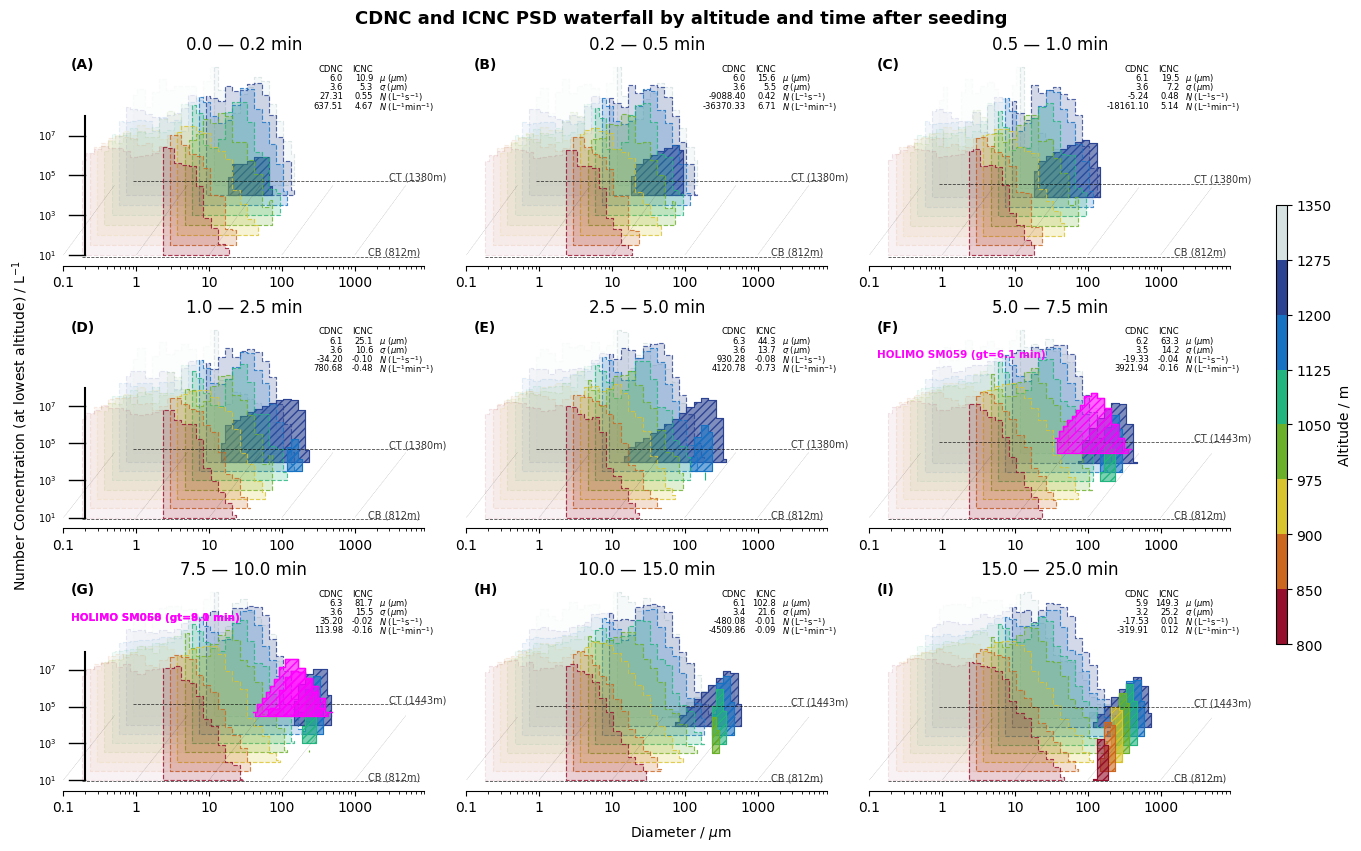

In [ ]:

# ##########################################
# MAIN PLOT CALL
# Example usage for figure 13

datasets = load_plume_path_runs(
    RUNS,
    processed_root=PROCESSED_ROOT,
    kinds=("vertical", "integrated"),
)

try:
    xlim = build_common_xlim(datasets, kind="integrated", span_min=35)
except ValueError:
    # Fallback window if no valid times are discoverable in current environment.
    xlim = [np.datetime64("2023-01-25T12:30:00"), np.datetime64("2023-01-25T13:04:00")]

diag = diagnostics_table(datasets, kind="integrated", variable="nf", xlim=xlim)
print(diag.to_string(index=False))



new_jet3_soft = make_pastel(new_jet3, desaturation=0.25, darken=0.90)
alt_bands = [(1350, 1275), (1275, 1200), (1200, 1125), (1125, 1050), (1050, 975), (975, 900), (900, 850), (850, 800)]

# Compatibility bridge: cleaned notebook usually defines `datasets` and `RUNS`.
if "cs_run_datasets" not in globals():
    if "datasets" not in globals():
        raise NameError("Neither 'cs_run_datasets' nor 'datasets' is defined. Run the data-loading cell first.")
    cs_run_datasets = datasets

if "cfg" not in globals():
    cfg = {
        run["label"]: {"flare_start_datetime": run.get("flare_start_datetime")}
        for run in globals().get("RUNS", [])
        if "label" in run
    }

cs_indices = list(cs_run_datasets.keys())
print(f"list of cs_indices:\n", "\n ".join(cs_indices))

# HOLIMO observational PSDs in requested order: SM059, SM058, SM060
holimo_obs = build_holimo_obs_series(ds_hd10, time_frames_plume, obs_ids, growth_times_min, var_candidates=["Ice_PSDnoNorm"])
from tqdm.auto import tqdm
time_windows = ["0.25min", "0.5min", "1min", "2.5min", "5min", "7.5min", "10min", "15min", "25min"]
zlim = (1e1, 1e8)
xlim = (1e-1, 9e3)
idx_dbg = 1

prepped_list = []
for cs_idx in tqdm(cs_indices[:idx_dbg]):
    # Prepare once (expensive), then reuse for plotting if figure style is adjusted.
    run_ds = cs_run_datasets[cs_idx]
    ds_case = run_ds.get("vertical", run_ds.get("integrated"))
    if ds_case is None:
        continue

    if "cell" in ds_case.dims:
        ds_case = ds_case.sum("cell")

    plot_nw, plot_nf = prepare_waterfall_inputs(ds_case)
    t0_cfg = cfg.get(cs_idx, {}).get("flare_start_datetime") if isinstance(cfg, dict) else None
    t0 = np.datetime64(t0_cfg) if t0_cfg else np.datetime64(ds_case.time.values.min(), "s")

    prepared = prepare_psd_waterfall_data(
        plot_nw,
        plot_nf,
        time_windows=time_windows,
        t0=np.datetime64("2023-01-25T12:30:00"),
        alt_bands=alt_bands,
        da_w=None,
        cmap=new_jet3_soft,
        x_shift=-0.1,
    )
    fig_wf_alt, axes_wf_alt = plot_psd_waterfall(
        prepared,
        alt_bands=alt_bands,
        zlim=zlim,
        xlim=xlim,
        cmap=new_jet3_soft,
        y_shift=-0.5,
        x_shift=-0.1,
        holimo_obs=holimo_obs,
    )

    fig_wf_alt.suptitle("CDNC and ICNC PSD waterfall by altitude and time after seeding", fontsize=13, weight="semibold")
    figure_file = f"figures/figure13_psd_waterfall_alt_time_{'_'.join(cs_idx.split('_')[:-1])}.png"
    fig_wf_alt.savefig(figure_file, bbox_inches="tight", dpi=300)
